### 학습목표
- 텍스트 데이터에서 수치화하는 다양한 방법에 대해서 알 수 있다.
- 문서, 문장, 단어 유사도에 대해서 확인할 수 있다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 구글마운트
# 파일위치변경
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [3]:
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Machine Learning/1.텍스트 마이닝


In [4]:
!pip install konlpy
# 키위라이브러리 설치
!pip install kiwipiepy
# Mecab 설치하기
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
!bash ./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 25.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 23.5 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=c150f1906eccd37ff04f90b6cfd1c0b076a4e8e5ea68e20553202913e3cda489
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model
fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-02-20 02:30:53--  https://bitbucket.org/eunjeon/mecab-ko/downloads/m

### 1. 연관성, 유사도 분석
- 단어 또는 문서끼리 관련성이나 유사도를 파악하는 기술

##### 유사도
- Similarity: 데이터 사이에 비슷한 정도를 측정하는 방법
- 텍스트마이닝에서는 두 단어 사이의 관계, 두 문서사이의 관계를 측정할때 사용함
- 유사도의 데이터간 거리가 가까울수록 유사도가 높다고 판단, 대표적으로 2가지 거리 계산법
    1. 맨해튼거리(Manhattan Distance): 좌표사이의 절대값을 모두 더한 거리값
        - 격자 형태의 도로망에서 길을 찾아가는 것과 유사한 방식
    2. 유클리디안 거리(Euclidean Distance): 두 점 사이의 최단 직선 거리, 피타고라스 정리를 이용하여 계산하는 인공지능에서 가장 흔히 사용되는 방식

##### 거리기반 알고리즘
  1. Manhattan Distance  
  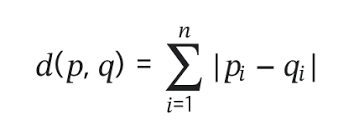
  2. Euclidean Distance  
  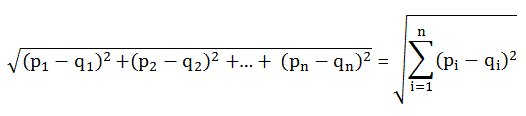

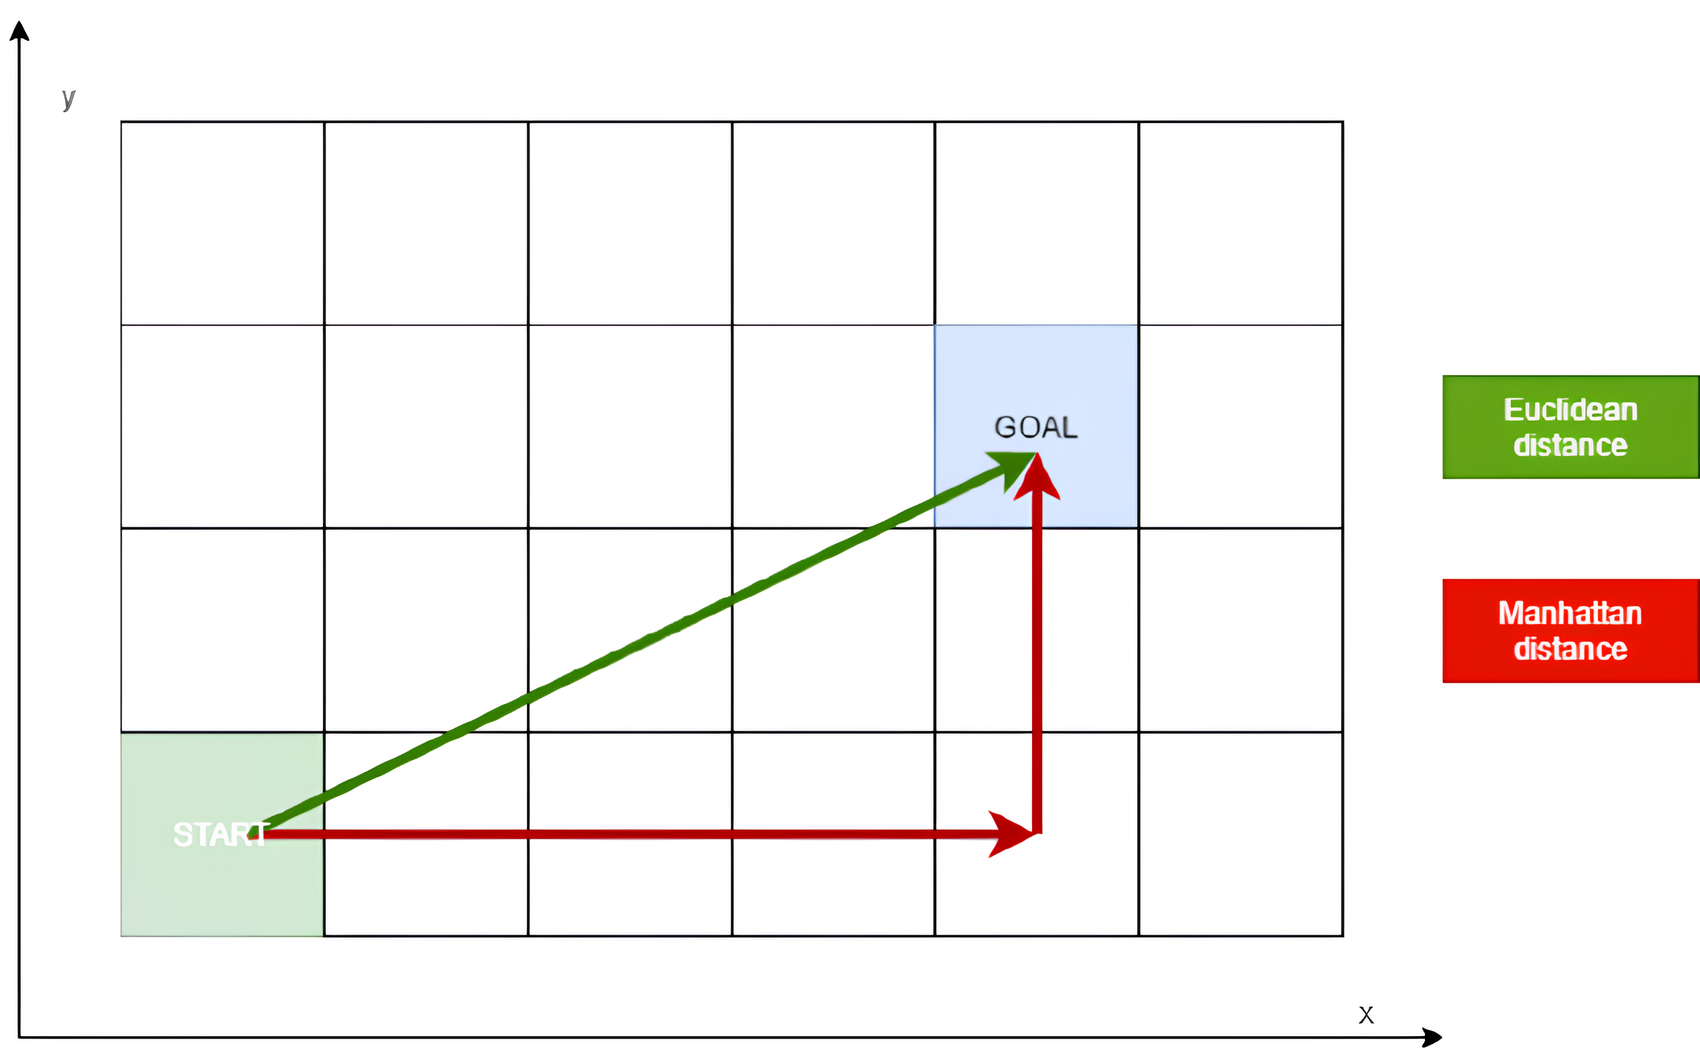

In [5]:
# 유클리디언 거리 공식 확인하기
import numpy as np
# 함수 정의
def euclidean_sim (A,B):
  return ((A-B) ** 2).sum()  ** 0.5

In [6]:
#숫자는 특정 단어가 나온 횟수

# doc1 = [0, 1, 1, 1] (사과 0번, 포도 1번, 배 1번, 귤 1번)
# doc2 = [1, 0, 1, 1] (사과 1번, 포도 0번, 배 1번, 귤 1번)
# doc3 = [3, 0, 3, 3] (사과 3번, 포도 0번, 배 3번, 귤 3번)

doc1 = np.array([0,1,1,1])
doc2 = np.array([1,0,1,1])
doc3 = np.array([3,0,3,3])
# 가설: 문서 2번과 3번이 유사할것이다!

In [7]:
# 거리계산을 통한 문서 유사도 확인
print("문서1과 문서 2의 유사도: ", euclidean_sim(doc1, doc2))
print("문서2과 문서 3의 유사도: ", euclidean_sim(doc2, doc3))
print("문서1과 문서 3의 유사도: ", euclidean_sim(doc1, doc3))

문서1과 문서 2의 유사도:  1.4142135623730951
문서2과 문서 3의 유사도:  3.4641016151377544
문서1과 문서 3의 유사도:  4.242640687119285


##### 결과 해석
- 문서 1과 문서 2의 유사도가 높게 나타남
- 왜? 단어 1,2 개만 다르게 계산되기 때문
- 실은 문서2, 3이 유사해 보이지만, 단지 글이 더 길다는 이유만으로 거리가 멀게 출력이 됨
- 유클리디언 거리는 글의 길이에 민감하게 반응, 단어가 유사하더라도 문서의 길이에 따라 유사도가 달라짐
- 그래서 글의 길이는 무시하고 방향(내용의 결)만 보는 측정방법이 필요해짐!!
- 코사인 유사도!!! (방향기반의 알고리즘)

### 방향기반 알고리즘
- 단순 거리기반의 유클리디언공식의 단점을 보완
- 코사인 유사도(Cosine Simliarity)
  - 두 벡터사이의 각도(코사인)으로 유사도를 계산
  - -1~1 사이의 값으로 도출
  - 문장의 질이, 단어수 등에 덜 민감하여 텍스트마이닝에서 선호
  - 값보다는 방향이 중요한 추천시스템 등에 활용

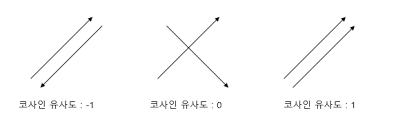

- 코사인 유사도 해석방법 (-1~1)
  - -1: 두 벡터가 완전히 반대방향, 정반대 개념 (ex 좋다:나쁘다, 성공:실패)
  - 0: 두 벡터가 직각, 의미적 관련이 없음 (ex 행복: 컴퓨터, 사과:정치)
  - 1: 두벡터가 완전히 같은 방향, 의미가 유사 (ex 행복:기쁨, 좋다:만족)

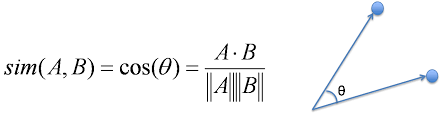

In [8]:
# 코사인 유사도 함수 만들기
from numpy import dot # 내적,행렬곱 등을 계산하는 함수
from numpy.linalg import norm # 벡터길이를 계산하는 함수

def cos_sim(A,B) :
  return dot(A,B) / (norm(A) * norm(B))

In [9]:
doc1 = np.array([0,1,1,1])
doc2 = np.array([1,0,1,1])
doc3 = np.array([3,0,3,3])
# 거리계산
print("문서1과 문서2의 유사도(거리) : ", cos_sim(doc1,doc2))
print("문서2과 문서3의 유사도(거리) : ", cos_sim(doc2,doc3))
print("문서1과 문서3의 유사도(거리) : ", cos_sim(doc1,doc3))
# 뉴스기사유사도, 추천시스템 등과 같이 텍스트마이닝 계열에서는
# 단순거리계산이 아닌 코사인유사도 방식을 활용하여 유사한 정도를 판별한다~

문서1과 문서2의 유사도(거리) :  0.6666666666666667
문서2과 문서3의 유사도(거리) :  1.0
문서1과 문서3의 유사도(거리) :  0.6666666666666666


### 워드 임베딩 (Word Embedding)
- 단어를 의미 보존한 채 벡터화(의미를 가진 수치화) 하는 방법
- 인공지능이 문서를 학습하며 단어사이의 관계를 비교하는 방법
- 단순 수치화하는 것이 아니라 의미적 관계를 포함하여 학습함
- 단어가 포함하는 정보가 풍부해진다~ (단순 빈도기반 보다 단어사이의 관계성을 포함하기 때문!)
- 단어 사이의 관계성이 숫자로 표현되지만 인공지능 학습하여 출력한 수치로서 어떤의미를 가지는 수치인지는 사람이 파악할 수 없음

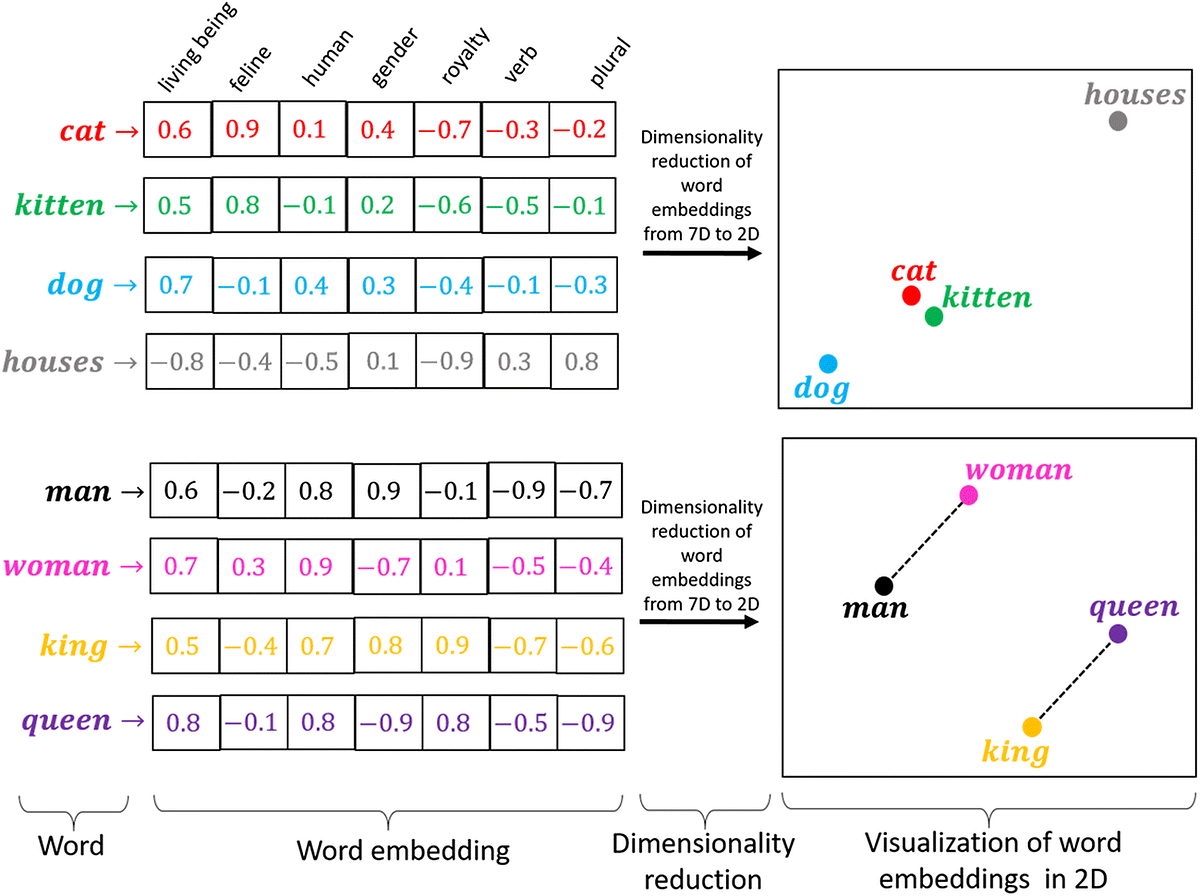

In [25]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.3 MB/s eta 0:00:00


In [161]:
# 네이버 쇼핑데이터 불러오기 (컬럼명설정 -> 평점, 리뷰)
import pandas as pd
data = pd.read_csv("./데이터/naver_shopping.txt",sep = '\t',header = None)
data.columns = ["평점","리뷰"]

In [162]:
data.head()

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [163]:
#mecab 형태소 분석기 활용하여 토큰화
from konlpy.tag import Mecab
mecab = Mecab()

In [164]:
#mecab을 활용하여 VV,VA,NNG 형태소 추출
data['형태소'] = data['리뷰'].apply(lambda x :[token[0] for token in mecab.pos(x) if token[1] in ["VV","VV","NNG"]])

In [165]:
data

,평점,리뷰,형태소
0,5,배공빠르고 굿,"[배공, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 집, 밑, 층, 말, 놔두]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 성비, 최고]"
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 받, 전달, 하, 상품, 머그, 컵, 당황, 전화, 주, 배송, 누락, 확..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]"
...,...,...,...
199995,2,장마라그런가!!! 달지않아요,"[장마, 달]"
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[구매, 슈퍼, 소닉, 케이스, 구매, 가격, 배송, 파, 슈퍼, 소닉, 케이스]"
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[로드, 사, 세배, 이용]"
199998,5,넘이쁘고 쎄련되보이네요~,[보이]


In [166]:
mecab.pos("아버지가 방에 들어가신다")[1][0]

'가'

- token[0] : 품사
- token[1] : 형태소 (단어)

In [167]:
#워드 임베딩 도구 불러오기
from gensim.models import Word2Vec
# 워드2벡 : 단어를 벡터로 -> 벡터란? 의미를 가지는 수치값

In [168]:
w2v = Word2Vec(
    sentences = [t for t in data['형태소']], # 한줄씩 전달해줘야함
    vector_size = 50, # 임베딩할 벡터의 크기 (한단어가 숫자로 표현되는 크기)
    min_count= 5, #  학습단어로 선정하기 위한 최소등장횟수
    window = 3 # 인접한 단어의 영역을 설정하는 수
)

In [169]:
w2v.wv.get_vector("배송")

array([ 0.35402066,  1.1225289 , -0.02625746,  0.00888703,  1.4325677 ,
       -0.84756684,  1.3286043 ,  0.58704996,  0.2606356 , -0.13935949,
       -0.6533218 , -0.35628963,  0.9961654 , -0.33762294,  0.09982432,
        0.42681885,  0.04500932, -0.04779102, -0.60540354, -0.14840604,
       -0.6947338 ,  1.0908451 ,  1.5024472 , -1.6170202 ,  0.3239916 ,
        0.8978149 , -0.55299014, -0.34964514, -1.0849236 , -0.28312644,
        0.33367613, -0.55592614,  0.9927388 , -0.58660674,  0.02714745,
        1.2325681 , -0.34144154, -1.7500732 , -2.1431897 , -0.2894551 ,
       -0.09710329, -1.0092672 ,  0.03369884, -0.77948165,  1.0462189 ,
        1.3779266 , -1.5671452 , -1.2006963 , -0.58089596,  0.13745302],
      dtype=float32)

In [170]:
# 전체 단어수 확인
len(w2v.wv)

8239

In [171]:
# 유사도 비교, 유클리디언 거리공식 활용
# 배송 배달 선물 유사도 비교
배송_vec = w2v.wv['배송']
배달_vec = w2v.wv['배달']
선물_vec = w2v.wv['선물']

In [172]:
# 유클리디언 거리계산
print("배송과 배달의 유사도: ", euclidean_sim(배송_vec, 배달_vec))
print("배달과 선물의 유사도: ", euclidean_sim(배달_vec, 선물_vec))
print("배송과 선물의 유사도: ", euclidean_sim(배송_vec, 선물_vec))

배송과 배달의 유사도:  3.994406
배달과 선물의 유사도:  8.317663
배송과 선물의 유사도:  8.68992


In [173]:
# 연관단어 확인
w2v.wv.most_similar('배송',topn=30) # 상위 30개 가장 연관성 높은 단어

[('배달', 0.7697089314460754),
 ('도착', 0.742443859577179),
 ('발송', 0.7123761177062988),
 ('착불', 0.7066317200660706),
 ('신속', 0.7031604647636414),
 ('결제', 0.6984270215034485),
 ('물품', 0.697114109992981),
 ('출고', 0.6903561353683472),
 ('맞교환', 0.6822132468223572),
 ('누락', 0.6810761094093323),
 ('결재', 0.6751395463943481),
 ('지연', 0.6626632809638977),
 ('수령', 0.6613407731056213),
 ('택배', 0.6606819033622742),
 ('안내', 0.6552002429962158),
 ('받', 0.6551479697227478),
 ('해외', 0.6482563018798828),
 ('날짜', 0.6472741961479187),
 ('불만', 0.6456642150878906),
 ('오', 0.6426095962524414),
 ('책정', 0.641613781452179),
 ('오전', 0.639691948890686),
 ('통보', 0.6388400197029114),
 ('약속', 0.6381683349609375),
 ('진행', 0.635941207408905),
 ('지역', 0.6341186761856079),
 ('지정', 0.6323283910751343),
 ('통운', 0.6295360922813416),
 ('물량', 0.6276087760925293),
 ('양호', 0.6262628436088562)]

- 네트워크 그래프 시각화

In [174]:
!pip install pyvis

In [175]:
from pyvis.network import Network

In [176]:
# 네트워크 생성
net = Network(notebook=True, cdn_resources='in_line' )
# 핵심단어
keyword = "고구마"
# 핵심단어의 연관성 있는 단어 확보
most_rs = w2v.wv.most_similar(keyword, topn=25)

# 중심노드 추가
net.add_node(keyword)
# 주변노드 추가
for w,s in most_rs : # 반복분으로 연관단어와 유사도를 처리
  net.add_node(w) # 연관단어 추가
  net.add_edge(w, keyword, value=s) # 엣지 추가
# 파일저장
net.save_graph("naver_shop_keywords.html")

In [177]:
# 주피터 노트북 내부에서 확인하기
from IPython.display import HTML
HTML(filename="naver_shop_keywords.html")

### 감성분석 + 단어 유사도 분석
1. 정답데이터 만들기
2. 리뷰데이터 수치화 (TF-IDF)
3. 모델링 (모델생성, 모델학습, 모델예측, 모델평가)


In [178]:
data

,평점,리뷰,형태소
0,5,배공빠르고 굿,"[배공, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 집, 밑, 층, 말, 놔두]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 성비, 최고]"
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 받, 전달, 하, 상품, 머그, 컵, 당황, 전화, 주, 배송, 누락, 확..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]"
...,...,...,...
199995,2,장마라그런가!!! 달지않아요,"[장마, 달]"
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[구매, 슈퍼, 소닉, 케이스, 구매, 가격, 배송, 파, 슈퍼, 소닉, 케이스]"
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[로드, 사, 세배, 이용]"
199998,5,넘이쁘고 쎄련되보이네요~,[보이]


In [179]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [180]:
#1. 정답데이터 만들기
data['label'] = data['평점'].apply(lambda x :1 if x>3 else 0)

In [181]:
data

,평점,리뷰,형태소,label
0,5,배공빠르고 굿,"[배공, 굿]",1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 집, 밑, 층, 말, 놔두]",0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 성비, 최고]",1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 받, 전달, 하, 상품, 머그, 컵, 당황, 전화, 주, 배송, 누락, 확...",0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]",1
...,...,...,...,...
199995,2,장마라그런가!!! 달지않아요,"[장마, 달]",0
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[구매, 슈퍼, 소닉, 케이스, 구매, 가격, 배송, 파, 슈퍼, 소닉, 케이스]",1
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[로드, 사, 세배, 이용]",1
199998,5,넘이쁘고 쎄련되보이네요~,[보이],1


In [182]:
#2. 리뷰데이터 수치화
data['형태소 문장'] = data['형태소'].apply(lambda x : " ".join(x))

In [183]:
data

,평점,리뷰,형태소,label,형태소 문장
0,5,배공빠르고 굿,"[배공, 굿]",1,배공 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 집, 밑, 층, 말, 놔두]",0,택배 집 밑 층 말 놔두
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 성비, 최고]",1,바지 구매 가격 대박 바느질 성비 최고
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 받, 전달, 하, 상품, 머그, 컵, 당황, 전화, 주, 배송, 누락, 확...",0,선물 받 전달 하 상품 머그 컵 당황 전화 주 배송 누락 확인 하 선물 배송 사 생각
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]",1,민트 색상 옆 손잡이 용도 사용
...,...,...,...,...,...
199995,2,장마라그런가!!! 달지않아요,"[장마, 달]",0,장마 달
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[구매, 슈퍼, 소닉, 케이스, 구매, 가격, 배송, 파, 슈퍼, 소닉, 케이스]",1,구매 슈퍼 소닉 케이스 구매 가격 배송 파 슈퍼 소닉 케이스
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[로드, 사, 세배, 이용]",1,로드 사 세배 이용
199998,5,넘이쁘고 쎄련되보이네요~,[보이],1,보이


In [184]:
# 단어사전 구축
tfidf.fit(data['형태소 문장'])

TfidfVectorizer()

In [185]:
len(tfidf.vocabulary_)

19867

In [186]:
print(tfidf.vocabulary_)

{'배공': 7009, '택배': 17589, '놔두': 3250, '바지': 6593, '구매': 1692, '가격': 8, '대박': 3781, '바느질': 6523, '성비': 9227, '최고': 16765, '선물': 9116, '전달': 14673, '상품': 8789, '머그': 5545, '당황': 3718, '전화': 14787, '배송': 7053, '누락': 3264, '확인': 19513, '생각': 8907, '민트': 6461, '색상': 8872, '손잡이': 9646, '용도': 12753, '사용': 8463, '비추': 8188, '계란': 1033, '뒤집': 4417, '완전': 12551, '불편': 7987, '코팅': 17271, '묻어나': 6186, '실용': 10595, '주문': 15401, '회사': 19590, '연락': 11957, '추천': 16840, '길이': 2385, '나오': 2708, '전문': 14691, '속옷': 9586, '브랜드': 8024, '위생': 13111, '팬티': 18141, '부분': 7692, '신축성': 10525, '반실': 6702, '사이즈': 8487, '늘어나': 3353, '살색': 8650, '가까워': 26, '화면': 19452, '컬러': 17198, '촉감': 16737, '무게': 5985, '친구': 17028, '실내': 10544, '이상': 13565, '가게': 7, '운영': 12934, '사장': 8495, '대신': 3805, '가성': 125, '바퀴': 6603, '고정': 1221, '화장': 19481, '거품': 704, '생기': 8924, '오랫동안': 12282, '세정력': 9339, '남자': 2841, '유해': 13289, '성분': 9226, '초등': 16680, '채집통': 16400, '결착': 943, '모서리': 5816, '해당': 18987, '제품': 15118, '불량': 7921, '보내': 

In [187]:
# 형태소 문장의 데이터를 수치화
review_result = tfidf.transform(data['형태소 문장'])

In [188]:
review_result.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [189]:
from sklearn.model_selection import train_test_split

In [190]:
X = review_result
y = data['label']

In [191]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,
                                                 random_state = 20,
                                                 stratify = y
)

In [192]:
print(X_train.shape,y_train.shape)

(140000, 19867) (140000,)


In [193]:
print(X_test.shape,y_test.shape)

(60000, 19867) (60000,)


In [194]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [195]:
model.fit(X_train,y_train)

LogisticRegression()

In [196]:
model.score(X_test,y_test)

0.7494833333333333

In [197]:
# 샘플문장 만들기
my_review = ['택배 배송 너무 빨라서 좋았어요. 최고 좋아',
             '이 옷은 오염 심해요. 기분이 나빠. 다시는 안살래요. 별로에요']

### 워드임베딩 결과로 모델링

In [198]:
w2v.wv['배송']

array([ 0.35402066,  1.1225289 , -0.02625746,  0.00888703,  1.4325677 ,
       -0.84756684,  1.3286043 ,  0.58704996,  0.2606356 , -0.13935949,
       -0.6533218 , -0.35628963,  0.9961654 , -0.33762294,  0.09982432,
        0.42681885,  0.04500932, -0.04779102, -0.60540354, -0.14840604,
       -0.6947338 ,  1.0908451 ,  1.5024472 , -1.6170202 ,  0.3239916 ,
        0.8978149 , -0.55299014, -0.34964514, -1.0849236 , -0.28312644,
        0.33367613, -0.55592614,  0.9927388 , -0.58660674,  0.02714745,
        1.2325681 , -0.34144154, -1.7500732 , -2.1431897 , -0.2894551 ,
       -0.09710329, -1.0092672 ,  0.03369884, -0.77948165,  1.0462189 ,
        1.3779266 , -1.5671452 , -1.2006963 , -0.58089596,  0.13745302],
      dtype=float32)

- 머신러닝 학습을 위하여 단어벡터의 평균을 구하여 문장벡터로 변환
- 각 단어마다 50차원의 벡터로 변환되었기 때문에 머신러닝 학습은 문장벡터가 필요
- 3개의 단어의 50차원 3개를 평균을 내서 하나의 50차원으로 변경

In [199]:
import numpy as np

def document_vector(doc, model):
    # 1. 사전에 존재하는 단어만 필터링
    words = [word for word in doc if word in model.wv]

    # 2. 유효 단어가 하나도 없을 경우 → 0벡터 반환
    if len(words) == 0:
        return np.zeros(model.vector_size)

    # 3. 평균 벡터 반환
    return np.mean(model.wv[words], axis=0)

In [200]:
X = np.array([document_vector(doc, w2v)
              for doc in data['형태소']])

In [201]:
X.shape

(200000, 50)

In [202]:
#데이터분리
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,
                                                 random_state = 20,
                                                 stratify = y)

In [203]:
from sklearn.linear_model import LogisticRegression
l_model = LogisticRegression()

In [204]:
l_model.fit(X_train,y_train)

LogisticRegression()

In [205]:
l_model.score(X_test,y_test)

0.7445166666666667

In [213]:
# 단어 토큰과 가중치 매칭
token_df = pd.DataFrame({'토큰':tfidf.vocabulary_.keys(),
                         '인덱스':tfidf.vocabulary_.values()})
token_df = token_df.sort_values(by='인덱스')
token_df['가중치']= model.coef_[0]

In [214]:
token_df # 벡터 모델은 사용하지 않고, 단어 개별가중치를 가지고 있는 모델을 활용해서 사용

,토큰,인덱스,가중치
18333,大王,0,0.000000
3788,寸鐵,1,0.311307
3789,殺人,2,0.311307
3092,가가,3,0.472241
13184,가각,4,-0.160755
...,...,...,...
11444,힘들이,19862,0.000000
18136,힘쓰,19863,0.371978
3520,힘주,19864,-0.368930
1793,힘줄,19865,-0.823067


In [215]:
np.where(token_df['가중치'])

array([ 0.        ,  0.31130722,  0.31130722, ..., -0.36892957,
       -0.82306738, -0.64377014])

In [216]:
token_df.sort_values(by="가중치",ascending=False)

,토큰,인덱스,가중치
9,최고,16765,5.305404
183,친절,17035,4.289085
193,강추,473,4.039895
127,만족,5320,3.913980
1866,안심,11088,3.651372
...,...,...,...
221,환불,19526,-5.678179
25,비추,8188,-7.425824
96,최악,16781,-7.536090
217,실망,10564,-7.838868


In [218]:
# 1보다 크면 긍정, -1 보다 작으면 중립, 그 사이값은 중립 > 세개의 카테고리를 분류
token_df['감성라벨'] = np.where(token_df['가중치'] > 1 , '긍정',
                            np.where(token_df['가중치'] < -1, '부정', '중립'))

In [219]:
token_df

,토큰,인덱스,가중치,감성라벨
18333,大王,0,0.000000,중립
3788,寸鐵,1,0.311307,중립
3789,殺人,2,0.311307,중립
3092,가가,3,0.472241,중립
13184,가각,4,-0.160755,중립
...,...,...,...,...
11444,힘들이,19862,0.000000,중립
18136,힘쓰,19863,0.371978,중립
3520,힘주,19864,-0.368930,중립
1793,힘줄,19865,-0.823067,중립


In [220]:
my_token_df = token_df.set_index("토큰").copy()

In [221]:
my_token_df

,인덱스,가중치,감성라벨
토큰,,,
大王,0,0.000000,중립
寸鐵,1,0.311307,중립
殺人,2,0.311307,중립
가가,3,0.472241,중립
가각,4,-0.160755,중립
...,...,...,...
힘들이,19862,0.000000,중립
힘쓰,19863,0.371978,중립
힘주,19864,-0.368930,중립


### 감성 네트워크 시각화

In [222]:
# 네트워크 생성
net = Network(notebook=True, cdn_resources='in_line' )
# 핵심단어
keyword = "신속"
# 핵심단어의 연관성 있는 단어 확보
most_rs = w2v.wv.most_similar(keyword, topn=25)

# 감성정보 추출
sentiment_labels = []
for w,s in most_rs :
  try : # 코드 실행시 예외상황을 처리하는 구문
    sr = my_token_df.loc[w,'감성라벨'] # 감성라벨을 문자열형태로 꺼내기
  except Exception as e : # 예외상황을 처리하는 문장
    sr = "없음"
  sentiment_labels.append(sr)

# 중심노드 추가
net.add_node(keyword)
# 색상 딕셔너리
color_map = {"긍정":"#6799FF", "부정":"#F15F5F", "중립":"#D5D5D5", "없음":"#D5D5D5"}
# 주변노드 추가
for (w,s),sr in zip(most_rs,sentiment_labels) : # 반복분으로 연관단어와 유사도, 감성라벨을 처리
  net.add_node(w, color=color_map[sr]) # 연관단어 추가
  net.add_edge(w, keyword, value=s) # 엣지 추가
# 파일저장
net.save_graph("naver_shop_keywords.html")

from IPython.display import HTML
HTML(filename="naver_shop_keywords.html")

In [72]:
rf.fit(X_train,y_train)

KeyboardInterrupt: 

In [ ]:
rf.score(X_test,y_test)